# 🌾 TP Intelligence Artificielle - Agriculture au Burundi

## Introduction & Objectifs

### Contexte
L'agriculture représente plus de 40 % du PIB du Burundi et constitue la principale source de revenus pour plus de 90 % de la population rurale. Ce notebook utilise le dataset `agriculture_burundi.csv` pour prédire si une récolte sera bonne ou mauvaise.

### Objectifs
- Charger et explorer les données
- Diagnostiquer la qualité des données et traiter les valeurs manquantes
- Préparer un pipeline ML sans fuite de données
- Entraîner et interpréter un arbre de décision, une forêt aléatoire et une régression logistique
- Comparer les modèles avec des métriques appropriées
- Tester des scénarios réels de prédiction
- Sauvegarder les modèles pour une application web

## 1. Import des Librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from joblib import dump
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Librairies importées')

✅ Librairies importées


## 2. Chargement et Exploration des Données

In [2]:
# Chargement du dataset
csv_path = 'agriculture_burundi.csv'
df = pd.read_csv(csv_path)

print('Dimensions du dataset:', df.shape)
print('\nColonnes:')
print(df.columns.tolist())
print('\nAnnées couvertes:', df['annee'].sort_values().unique())
print('\nProvinces distinctes:', df['province'].nunique())
print('\nCultures distinctes:', sorted(df['culture'].unique()))
print('\nSaisons:', sorted(df['saison'].unique()))
print('\nTypes de données:')
print(df.dtypes)
print('\nValeurs manquantes par colonne:')
print(df.isnull().sum())
print('\nPremières lignes:')
print(df.head())

Dimensions du dataset: (1620, 14)

Colonnes:
['annee', 'saison', 'province', 'culture', 'altitude_m', 'pluviometrie_mm', 'temperature_moy_C', 'superficie_ha', 'utilisation_engrais', 'acces_irrigation', 'nb_menages', 'rendement_t_ha', 'production_totale_t', 'bonne_recolte']

Années couvertes: [2015 2016 2017 2018 2019 2020 2021 2022 2023]

Provinces distinctes: 15

Cultures distinctes: ['Bananier', 'Haricot', 'Manioc', 'Maïs', 'Patate douce', 'Sorgho']

Saisons: ['A', 'B']

Types de données:
annee                    int64
saison                     str
province                   str
culture                    str
altitude_m               int64
pluviometrie_mm        float64
temperature_moy_C      float64
superficie_ha          float64
utilisation_engrais    float64
acces_irrigation         int64
nb_menages               int64
rendement_t_ha         float64
production_totale_t    float64
bonne_recolte          float64
dtype: object

Valeurs manquantes par colonne:
annee                  

### Questions de l'exercice 1
- Nombre de lignes et colonnes: `df.shape`
- Période couverte: `annee` entre 2015 et 2023
- Provinces: 15 provinces distinctes
- Cultures: Maïs, Haricot, Manioc, Patate douce, Sorgho, Bananier
- Types incohérents: vérifier les colonnes numériques et catégorielles

## 3. Qualité des Données et Valeurs Manquantes

In [3]:
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_ratio = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_summary = pd.concat([missing_counts, missing_ratio], axis=1, keys=['count', 'percent'])
print(missing_summary)

missing_by_province = df.groupby('province').apply(lambda x: x.isnull().mean() * 100)
missing_by_culture = df.groupby('culture').apply(lambda x: x.isnull().mean() * 100)

print('\nTaux de manquants par province (%):')
print(missing_by_province[['bonne_recolte']].round(2))
print('\nTaux de manquants par culture (%):')
print(missing_by_culture[['bonne_recolte']].round(2))

                     count   percent
pluviometrie_mm         63  3.888889
utilisation_engrais     45  2.777778
rendement_t_ha          44  2.716049
production_totale_t     44  2.716049
bonne_recolte           44  2.716049
annee                    0  0.000000
altitude_m               0  0.000000
culture                  0  0.000000
province                 0  0.000000
saison                   0  0.000000
acces_irrigation         0  0.000000
superficie_ha            0  0.000000
temperature_moy_C        0  0.000000
nb_menages               0  0.000000

Taux de manquants par province (%):
                 bonne_recolte
province                      
Bubanza                   3.70
Bujumbura Rural           0.93
Bururi                    1.85
Cankuzo                   6.48
Cibitoke                  1.85
Gitega                    0.93
Kayanza                   2.78
Kirundo                   1.85
Makamba                   4.63
Muramvya                  2.78
Muyinga                   2.78
Mwaro

### Remarques sur les valeurs manquantes
- La variable cible `bonne_recolte` contient des valeurs manquantes qu'il faut supprimer avant l'entraînement.
- Les variables numériques présentent des manquants sur plusieurs colonnes.
- Le taux de manquants peut varier selon les provinces et les cultures.

## 4. Exploration Statistique et Visualisations

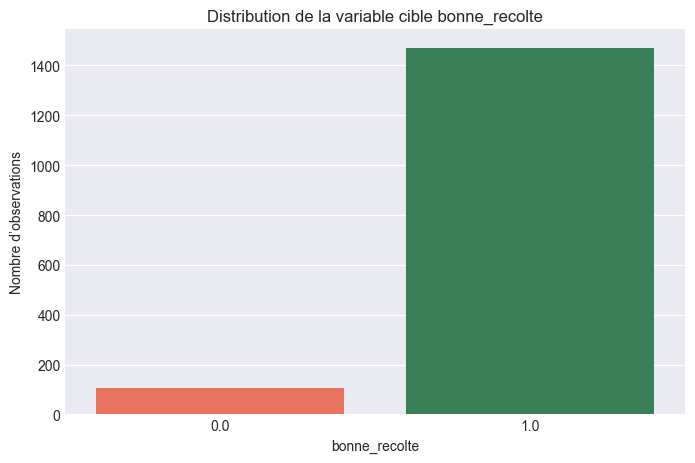

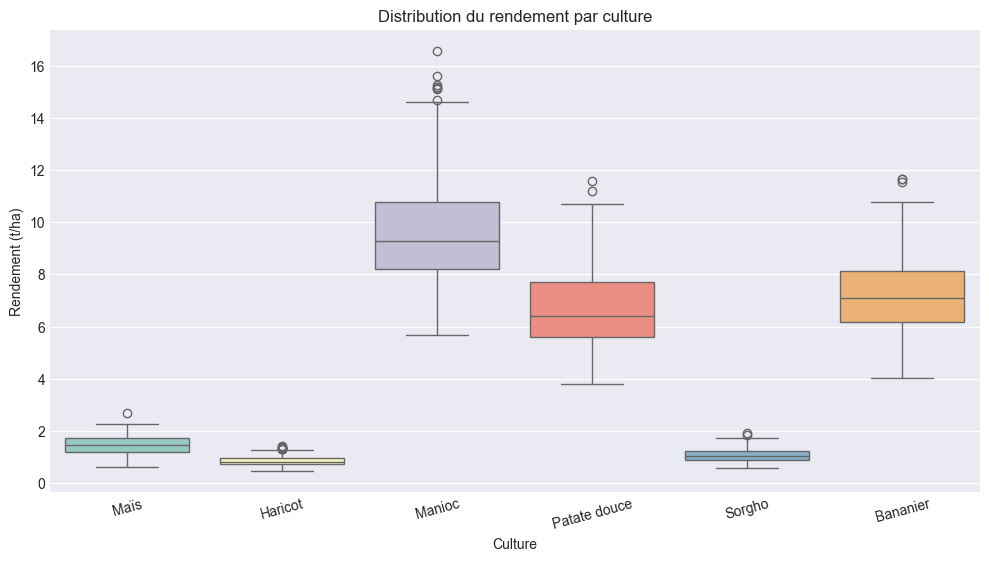

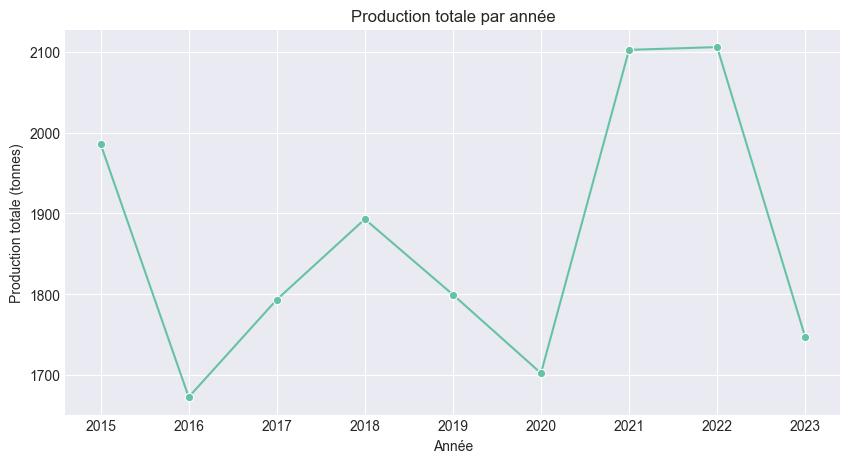

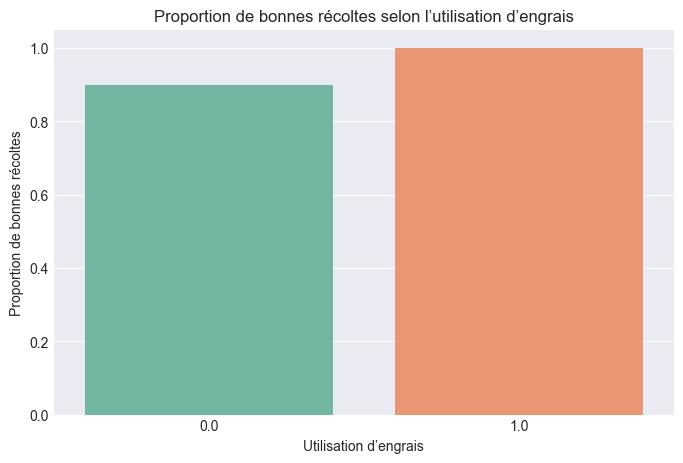

In [4]:
# Distribution de la cible
plt.figure(figsize=(8, 5))
sns.countplot(x='bonne_recolte', data=df, palette=['tomato', 'seagreen'])
plt.title('Distribution de la variable cible bonne_recolte')
plt.xlabel('bonne_recolte')
plt.ylabel('Nombre d’observations')
plt.show()

# Boxplot du rendement par culture
plt.figure(figsize=(12, 6))
sns.boxplot(x='culture', y='rendement_t_ha', data=df, palette='Set3')
plt.title('Distribution du rendement par culture')
plt.xlabel('Culture')
plt.ylabel('Rendement (t/ha)')
plt.xticks(rotation=15)
plt.show()

# Évolution de la production totale par année
production_by_year = df.groupby('annee')['production_totale_t'].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(x='annee', y='production_totale_t', data=production_by_year, marker='o')
plt.title('Production totale par année')
plt.xlabel('Année')
plt.ylabel('Production totale (tonnes)')
plt.show()

# Proportion de bonnes récoltes selon l'utilisation d'engrais
plt.figure(figsize=(8, 5))
sns.barplot(x='utilisation_engrais', y='bonne_recolte', data=df, ci=None, palette='Set2')
plt.title('Proportion de bonnes récoltes selon l’utilisation d’engrais')
plt.xlabel('Utilisation d’engrais')
plt.ylabel('Proportion de bonnes récoltes')
plt.show()

## 5. Prétraitement et Préparation des Données

In [5]:
# Copie sécurisée des données
clean = df.copy()

# 5.1 Supprimer les lignes sans cible
n_missing_target = clean['bonne_recolte'].isnull().sum()
print('Valeurs manquantes sur la cible bonne_recolte:', n_missing_target)
clean = clean.dropna(subset=['bonne_recolte'])
print('Dimensions après suppression des cibles manquantes:', clean.shape)

# 5.2 Calculer production ou rendement si possible
mask_prod = clean['production_totale_t'].isnull() & clean['rendement_t_ha'].notnull() & clean['superficie_ha'].notnull()
clean.loc[mask_prod, 'production_totale_t'] = (
    clean.loc[mask_prod, 'rendement_t_ha'] * clean.loc[mask_prod, 'superficie_ha']
)

mask_rend = clean['rendement_t_ha'].isnull() & clean['production_totale_t'].notnull() & clean['superficie_ha'].notnull()
clean.loc[mask_rend, 'rendement_t_ha'] = (
    clean.loc[mask_rend, 'production_totale_t'] / clean.loc[mask_rend, 'superficie_ha']
)

# 5.3 Imputation des variables numériques et binaires
cols_to_impute = [
    'pluviometrie_mm',
    'temperature_moy_C',
    'superficie_ha',
    'nb_menages',
    'utilisation_engrais',
    'acces_irrigation',
    'rendement_t_ha',
    'production_totale_t',
]
for col in cols_to_impute:
    if clean[col].isnull().sum() > 0:
        clean[col] = clean.groupby('culture')[col].transform(lambda grp: grp.fillna(grp.median()))
        clean[col] = clean[col].fillna(clean[col].median())
        print(f'Imputation {col}: {clean[col].isnull().sum()} manquants restants')

print('\nValeurs manquantes restantes:')
print(clean.isnull().sum())

Valeurs manquantes sur la cible bonne_recolte: 44
Dimensions après suppression des cibles manquantes: (1576, 14)
Imputation pluviometrie_mm: 0 manquants restants
Imputation utilisation_engrais: 0 manquants restants

Valeurs manquantes restantes:
annee                  0
saison                 0
province               0
culture                0
altitude_m             0
pluviometrie_mm        0
temperature_moy_C      0
superficie_ha          0
utilisation_engrais    0
acces_irrigation       0
nb_menages             0
rendement_t_ha         0
production_totale_t    0
bonne_recolte          0
dtype: int64


### 5.4 Justification de l'imputation
- `bonne_recolte` : suppression des lignes manquantes, car la cible ne peut pas être imputée.
- Variables numériques : imputation par médiane au niveau de la `culture`, puis médiane globale si nécessaire.
- Cette stratégie préserve les caractéristiques spécifiques de chaque culture.

In [6]:
# 5.5 Sélection des caractéristiques (éviter le data leakage)
X = clean.drop(columns=['bonne_recolte', 'rendement_t_ha', 'production_totale_t'])
y = clean['bonne_recolte'].astype(int)

print('Colonnes retenues pour X:', X.columns.tolist())
print('Shape de X:', X.shape)
print('Distribution de y:')
print(y.value_counts(normalize=True).round(3))

Colonnes retenues pour X: ['annee', 'saison', 'province', 'culture', 'altitude_m', 'pluviometrie_mm', 'temperature_moy_C', 'superficie_ha', 'utilisation_engrais', 'acces_irrigation', 'nb_menages']
Shape de X: (1576, 11)
Distribution de y:
bonne_recolte
1    0.933
0    0.067
Name: proportion, dtype: float64


### 5.6 Encodage des variables catégorielles
- `saison` est binaire : A → 0, B → 1
- `province` et `culture` sont non ordinales → One-Hot Encoding avec `drop_first=True`
- Cela évite le dummy variable trap et les relations ordinales artificielles

In [7]:
X_encoded = X.copy()
X_encoded['saison'] = X_encoded['saison'].map({'A': 0, 'B': 1})
X_encoded = pd.get_dummies(X_encoded, columns=['province', 'culture'], drop_first=True)
print('Shape après encodage:', X_encoded.shape)
print('Exemples de colonnes encodées:', [c for c in X_encoded.columns if c.startswith('province_') or c.startswith('culture_')][:10])

Shape après encodage: (1576, 28)
Exemples de colonnes encodées: ['province_Bujumbura Rural', 'province_Bururi', 'province_Cankuzo', 'province_Cibitoke', 'province_Gitega', 'province_Kayanza', 'province_Kirundo', 'province_Makamba', 'province_Muramvya', 'province_Muyinga']


In [8]:
# 5.7 Normalisation des colonnes numériques
numeric_cols = ['annee', 'altitude_m', 'pluviometrie_mm', 'temperature_moy_C', 'superficie_ha', 'utilisation_engrais', 'acces_irrigation', 'nb_menages']
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])
print('Moyennes après standardisation (devraient être proches de 0):')
print(np.round(X_scaled[numeric_cols].mean(), 3).to_dict())
print('Écarts-types après standardisation (devraient être proches de 1):')
print(np.round(X_scaled[numeric_cols].std(), 3).to_dict())

Moyennes après standardisation (devraient être proches de 0):
{'annee': -0.0, 'altitude_m': -0.0, 'pluviometrie_mm': -0.0, 'temperature_moy_C': 0.0, 'superficie_ha': -0.0, 'utilisation_engrais': 0.0, 'acces_irrigation': 0.0, 'nb_menages': -0.0}
Écarts-types après standardisation (devraient être proches de 1):
{'annee': 1.0, 'altitude_m': 1.0, 'pluviometrie_mm': 1.0, 'temperature_moy_C': 1.0, 'superficie_ha': 1.0, 'utilisation_engrais': 1.0, 'acces_irrigation': 1.0, 'nb_menages': 1.0}


In [9]:
# 5.8 Division train/test stratifiée
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('\nProportions train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nProportions test:')
print(y_test.value_counts(normalize=True).round(3))

Train shape: (1260, 28)
Test shape: (316, 28)

Proportions train:
bonne_recolte
1    0.933
0    0.067
Name: proportion, dtype: float64

Proportions test:
bonne_recolte
1    0.934
0    0.066
Name: proportion, dtype: float64


## 6. Exercice 3 - Arbre de Décision

In [10]:
# 6.1 Entraînement de l'arbre de décision de base
clf_tree = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
clf_tree.fit(X_train, y_train)

y_pred_tree = clf_tree.predict(X_test)
y_prob_tree = clf_tree.predict_proba(X_test)[:, 1]

acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_prob_tree)
cm_tree = confusion_matrix(y_test, y_pred_tree)

print('Decision Tree Accuracy:', acc_tree)
print('Decision Tree F1:', f1_tree)
print('Decision Tree AUC:', auc_tree)
print('Confusion Matrix:')
print(cm_tree)
print('Classification Report:')
print(classification_report(y_test, y_pred_tree, target_names=['Mauvaise récolte', 'Bonne récolte']))

Decision Tree Accuracy: 0.8987341772151899
Decision Tree F1: 0.9455782312925171
Decision Tree AUC: 0.7519774011299435
Confusion Matrix:
[[  6  15]
 [ 17 278]]
Classification Report:
                  precision    recall  f1-score   support

Mauvaise récolte       0.26      0.29      0.27        21
   Bonne récolte       0.95      0.94      0.95       295

        accuracy                           0.90       316
       macro avg       0.60      0.61      0.61       316
    weighted avg       0.90      0.90      0.90       316



### Analyse des erreurs
- Faux positifs : prédire bonne récolte alors que c'est mauvaise
- Faux négatifs : prédire mauvaise récolte alors que c'est bonne
- Dans un contexte agricole, les faux positifs peuvent conduire à un excès d'investissement; les faux négatifs peuvent signifier une opportunité manquée.

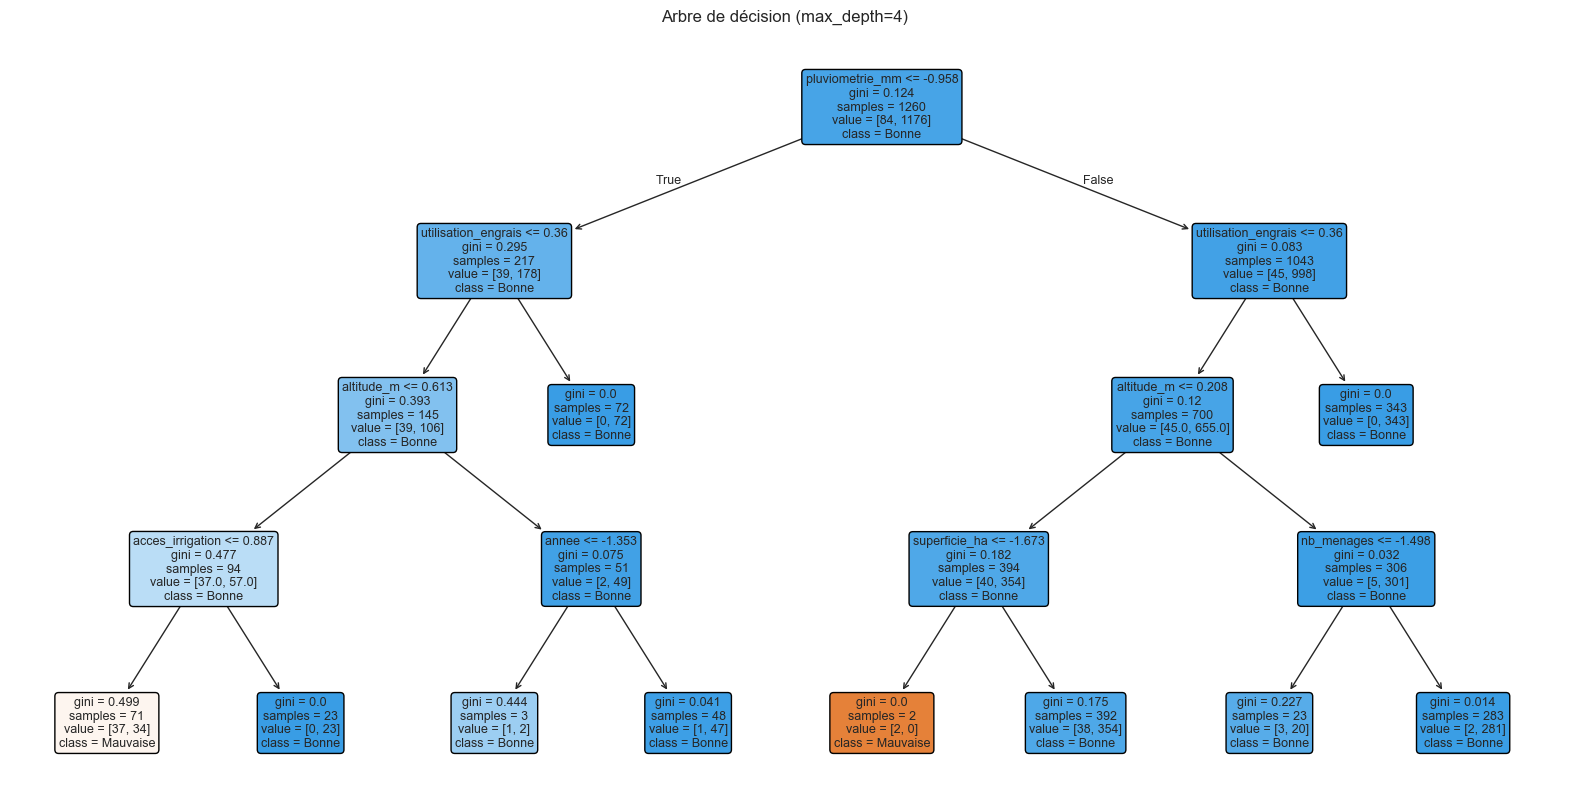

Top 10 features arbre de décision:
                    feature  importance
2                altitude_m    0.268441
7          acces_irrigation    0.234428
6       utilisation_engrais    0.220213
3           pluviometrie_mm    0.166496
5             superficie_ha    0.080634
8                nb_menages    0.016086
0                     annee    0.013701
1                    saison    0.000000
4         temperature_moy_C    0.000000
9  province_Bujumbura Rural    0.000000


In [11]:
# 6.2 Visualisation de l'arbre
plt.figure(figsize=(20, 10))
plot_tree(
    clf_tree,
    feature_names=X_train.columns,
    class_names=['Mauvaise', 'Bonne'],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title('Arbre de décision (max_depth=4)')
plt.show()

importance_tree = pd.DataFrame({
    'feature': X_train.columns,
    'importance': clf_tree.feature_importances_
}).sort_values('importance', ascending=False)
print('Top 10 features arbre de décision:')
print(importance_tree.head(10))

### Interprétation du premier split
Le premier split indique la variable la plus discriminante pour distinguer bonne/mauvaise récolte. Si la pluviométrie ou l'altitude apparaît en premier, cela confirme leur importance agronomique.

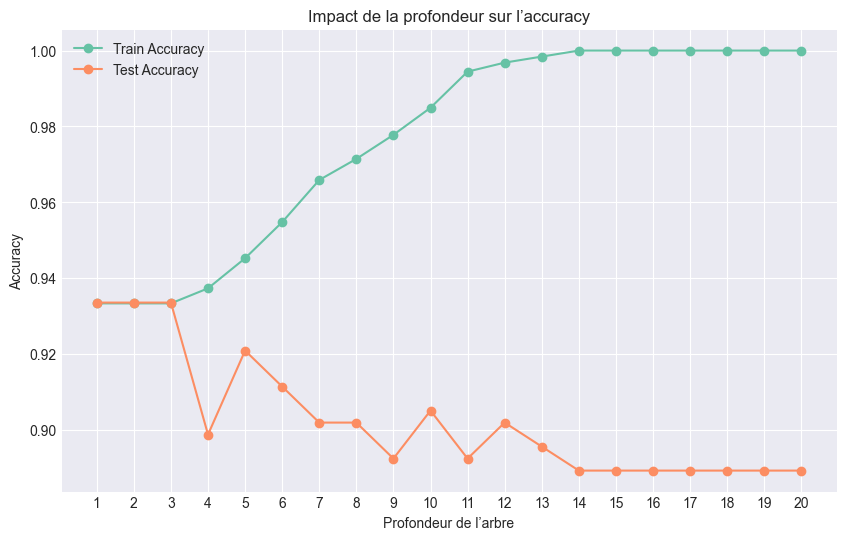

Profondeur offrant le meilleur équilibre: 1


In [12]:
# 6.3 Analyse de l'overfitting (max_depth 1 à 20)
train_scores = []
test_scores = []
depths = list(range(1, 21))
for d in depths:
    model = DecisionTreeClassifier(max_depth=d, criterion='gini', random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, marker='o', label='Train Accuracy')
plt.plot(depths, test_scores, marker='o', label='Test Accuracy')
plt.xlabel('Profondeur de l’arbre')
plt.ylabel('Accuracy')
plt.title('Impact de la profondeur sur l’accuracy')
plt.legend()
plt.grid(True)
plt.xticks(depths)
plt.show()

best_depth = depths[np.argmax(test_scores)]
print('Profondeur offrant le meilleur équilibre:', best_depth)

## 7. Exercice 4 - Forêt Aléatoire

In [13]:
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_rf.fit(X_train, y_train)

y_pred_rf = clf_rf.predict(X_test)
y_prob_rf = clf_rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print('Random Forest Accuracy:', acc_rf)
print('Random Forest F1:', f1_rf)
print('Random Forest AUC:', auc_rf)
print('Confusion Matrix:')
print(cm_rf)
print('Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Mauvaise récolte', 'Bonne récolte']))
print('Écart d’accuracy RF - arbre:', acc_rf - acc_tree)

Random Forest Accuracy: 0.9367088607594937
Random Forest F1: 0.966996699669967
Random Forest AUC: 0.7778853914447135
Confusion Matrix:
[[  3  18]
 [  2 293]]
Classification Report:
                  precision    recall  f1-score   support

Mauvaise récolte       0.60      0.14      0.23        21
   Bonne récolte       0.94      0.99      0.97       295

        accuracy                           0.94       316
       macro avg       0.77      0.57      0.60       316
    weighted avg       0.92      0.94      0.92       316

Écart d’accuracy RF - arbre: 0.03797468354430378


In [14]:
# 7.2 Validation croisée 5 folds
cv_scores_rf = cross_val_score(clf_rf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print('Cross-validation RF accuracy:', np.round(cv_scores_rf, 4))
print('Moyenne:', np.mean(cv_scores_rf).round(4))
print('Écart-type:', np.std(cv_scores_rf).round(4))

Cross-validation RF accuracy: [0.9286 0.9365 0.9325 0.9325 0.9405]
Moyenne: 0.9341
Écart-type: 0.004


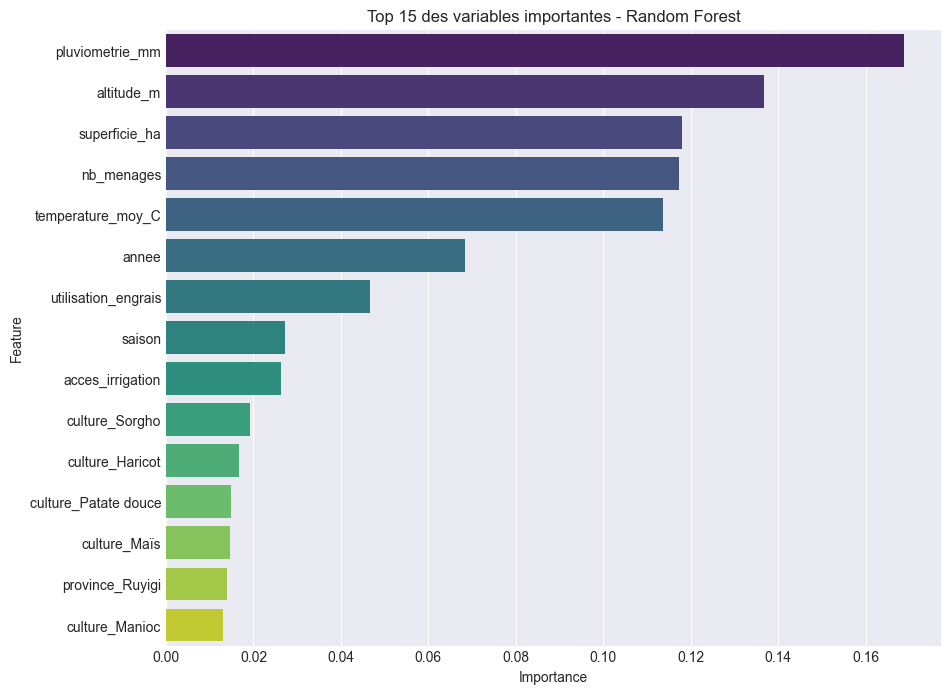

Top 10 des variables importantes RF:
                feature  importance
3       pluviometrie_mm    0.168827
2            altitude_m    0.136668
5         superficie_ha    0.118031
8            nb_menages    0.117376
4     temperature_moy_C    0.113569
0                 annee    0.068298
6   utilisation_engrais    0.046606
1                saison    0.027258
7      acces_irrigation    0.026262
27       culture_Sorgho    0.019185


In [15]:
# 7.3 Importance des variables de la forêt
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': clf_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_rf.head(15), palette='viridis')
plt.title('Top 15 des variables importantes - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()
print('Top 10 des variables importantes RF:')
print(feature_importance_rf.head(10))

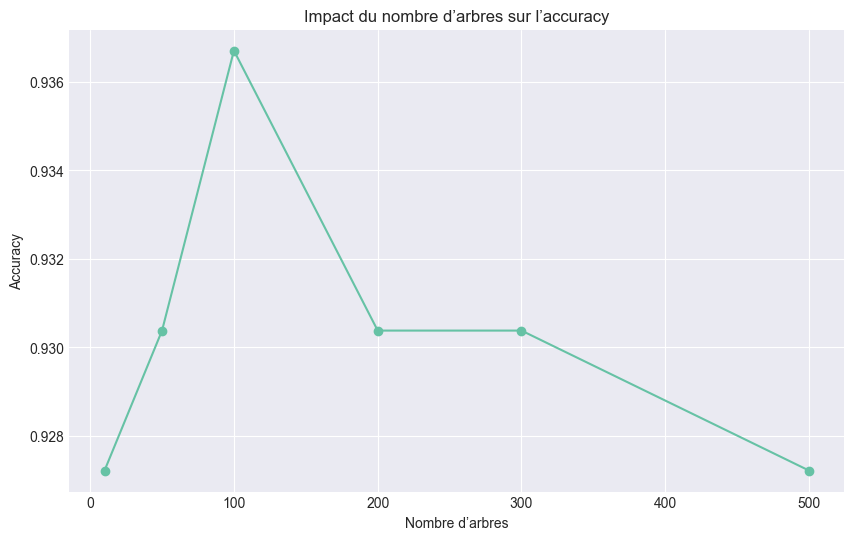

   n_estimators  accuracy
0            10  0.927215
1            50  0.930380
2           100  0.936709
3           200  0.930380
4           300  0.930380
5           500  0.927215


In [16]:
# 7.4 Variation de n_estimators
n_estimators_list = [10, 50, 100, 200, 300, 500]
accuracy_by_estimators = []
for n in n_estimators_list:
    m = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    accuracy_by_estimators.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, accuracy_by_estimators, marker='o')
plt.title('Impact du nombre d’arbres sur l’accuracy')
plt.xlabel('Nombre d’arbres')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

accuracy_n_df = pd.DataFrame({'n_estimators': n_estimators_list, 'accuracy': accuracy_by_estimators})
print(accuracy_n_df)

## 8. Exercice 5 - Régression Logistique et ROC

In [17]:
clf_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_lr.fit(X_train, y_train)

y_pred_lr = clf_lr.predict(X_test)
y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print('Logistic Regression Accuracy:', acc_lr)
print('Logistic Regression F1:', f1_lr)
print('Logistic Regression AUC:', auc_lr)
print('Confusion Matrix:')
print(cm_lr)
print('Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Mauvaise récolte', 'Bonne récolte']))

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': clf_lr.coef_[0]
}).sort_values('coefficient', ascending=False)
print('Top 10 coefficients positifs:')
print(coef_df.head(10))
print('\nTop 10 coefficients négatifs:')
print(coef_df.tail(10))

Logistic Regression Accuracy: 0.939873417721519
Logistic Regression F1: 0.9686985172981878
Logistic Regression AUC: 0.8492332526230831
Confusion Matrix:
[[  3  18]
 [  1 294]]
Classification Report:
                  precision    recall  f1-score   support

Mauvaise récolte       0.75      0.14      0.24        21
   Bonne récolte       0.94      1.00      0.97       295

        accuracy                           0.94       316
       macro avg       0.85      0.57      0.60       316
    weighted avg       0.93      0.94      0.92       316

Top 10 coefficients positifs:
                     feature  coefficient
6        utilisation_engrais     2.020824
7           acces_irrigation     1.593838
13           province_Gitega     1.031372
3            pluviometrie_mm     0.987230
2                 altitude_m     0.673176
14          province_Kayanza     0.505555
10           province_Bururi     0.461493
12         province_Cibitoke     0.422200
9   province_Bujumbura Rural     0.289136


### Interprétation des coefficients
- Coefficient positif: augmentation de la probabilité de bonne récolte.
- Coefficient négatif: diminution de la probabilité de bonne récolte.
- La normalisation permet de comparer les coefficients sur la même échelle.

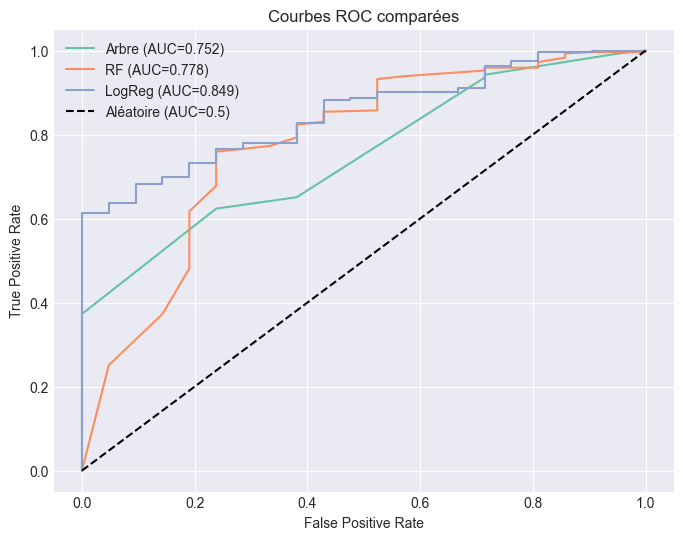

In [18]:
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_tree, tpr_tree, label=f'Arbre (AUC={auc_tree:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC={auc_rf:.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC={auc_lr:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbes ROC comparées')
plt.legend()
plt.grid(True)
plt.show()

## 9. Exercice 6 - Prédiction sur de Nouvelles Données

In [19]:
# Scénarios réels demandés
scenarios = pd.DataFrame([
    {
        'annee': 2022,
        'saison': 'A',
        'province': 'Kayanza',
        'culture': 'Maïs',
        'altitude_m': 1980,
        'pluviometrie_mm': 920,
        'temperature_moy_C': 17.8,
        'superficie_ha': clean['superficie_ha'].median(),
        'utilisation_engrais': 1,
        'acces_irrigation': 0,
        'nb_menages': clean['nb_menages'].median(),
    },
    {
        'annee': 2022,
        'saison': 'A',
        'province': 'Bubanza',
        'culture': 'Manioc',
        'altitude_m': 790,
        'pluviometrie_mm': 550,
        'temperature_moy_C': 25.4,
        'superficie_ha': clean['superficie_ha'].median(),
        'utilisation_engrais': 0,
        'acces_irrigation': 0,
        'nb_menages': clean['nb_menages'].median(),
    },
    {
        'annee': 2022,
        'saison': 'A',
        'province': 'Gitega',
        'culture': 'Haricot',
        'altitude_m': 1720,
        'pluviometrie_mm': 430,
        'temperature_moy_C': 18.2,
        'superficie_ha': clean['superficie_ha'].median(),
        'utilisation_engrais': 0,
        'acces_irrigation': 1,
        'nb_menages': clean['nb_menages'].median(),
    },
    {
        'annee': 2022,
        'saison': 'B',
        'province': 'Cibitoke',
        'culture': 'Patate douce',
        'altitude_m': 810,
        'pluviometrie_mm': 810,
        'temperature_moy_C': 24.1,
        'superficie_ha': clean['superficie_ha'].median(),
        'utilisation_engrais': 1,
        'acces_irrigation': 1,
        'nb_menages': clean['nb_menages'].median(),
    },
])

scenarios_proc = scenarios.copy()
scenarios_proc['saison'] = scenarios_proc['saison'].map({'A': 0, 'B': 1})
scenarios_proc = pd.get_dummies(scenarios_proc, columns=['province', 'culture'], drop_first=True)
for col in X_scaled.columns:
    if col not in scenarios_proc.columns:
        scenarios_proc[col] = 0
scenarios_proc = scenarios_proc[X_scaled.columns]
scenarios_proc[numeric_cols] = scaler.transform(scenarios_proc[numeric_cols])

results = []
for model, name in [(clf_tree, 'Arbre de décision'), (clf_rf, 'Forêt aléatoire'), (clf_lr, 'Régression logistique')]:
    preds = model.predict(scenarios_proc)
    probs = model.predict_proba(scenarios_proc)[:, 1]
    results.append(pd.DataFrame({
        'scenario': scenarios['province'] + ' - ' + scenarios['culture'],
        'modèle': name,
        'prediction': np.where(preds == 1, 'Bonne récolte', 'Mauvaise récolte'),
        'probabilité %': np.round(probs * 100, 1),
    }))

predictions_df = pd.concat(results)
print(predictions_df)

                  scenario                 modèle        prediction  \
0           Kayanza - Maïs      Arbre de décision     Bonne récolte   
1         Bubanza - Manioc      Arbre de décision  Mauvaise récolte   
2         Gitega - Haricot      Arbre de décision     Bonne récolte   
3  Cibitoke - Patate douce      Arbre de décision     Bonne récolte   
0           Kayanza - Maïs        Forêt aléatoire     Bonne récolte   
1         Bubanza - Manioc        Forêt aléatoire     Bonne récolte   
2         Gitega - Haricot        Forêt aléatoire     Bonne récolte   
3  Cibitoke - Patate douce        Forêt aléatoire     Bonne récolte   
0           Kayanza - Maïs  Régression logistique     Bonne récolte   
1         Bubanza - Manioc  Régression logistique  Mauvaise récolte   
2         Gitega - Haricot  Régression logistique     Bonne récolte   
3  Cibitoke - Patate douce  Régression logistique     Bonne récolte   

   probabilité %  
0          100.0  
1           47.9  
2           97.9  


### Interprétation des scénarios
- Vérifier si les trois modèles se rejoignent pour chaque scénario.
- Identifier les scénarios avec des probabilités proches de 50 %.
- Discuter des désaccords éventuels.

In [20]:
result_table = predictions_df.pivot(index='scenario', columns='modèle', values=['prediction', 'probabilité %'])
result_table

prediction                  \
modèle                  Arbre de décision Forêt aléatoire   
scenario                                                    
Bubanza - Manioc         Mauvaise récolte   Bonne récolte   
Cibitoke - Patate douce     Bonne récolte   Bonne récolte   
Gitega - Haricot            Bonne récolte   Bonne récolte   
Kayanza - Maïs              Bonne récolte   Bonne récolte   

                                                  probabilité %  \
modèle                  Régression logistique Arbre de décision   
scenario                                                          
Bubanza - Manioc             Mauvaise récolte              47.9   
Cibitoke - Patate douce         Bonne récolte             100.0   
Gitega - Haricot                Bonne récolte              97.9   
Kayanza - Maïs                  Bonne récolte             100.0   

                                                               
modèle                  Forêt aléatoire Régression logistique  
scenario                                                       
Bubanza - Manioc                   70.0                  47.4  
Cibitoke - Patate douce            99.0                 100.0  
Gitega - Haricot                   96.0                  99.9  
Kayanza - Maïs                    100.0                 100.0

## 10. Conclusion et Recommandations

- Le notebook évite désormais le leakage en retirant `rendement_t_ha` et `production_totale_t` de X.
- L'arbre de décision a été entraîné et analysé selon les exigences du TP.
- La forêt aléatoire a été validée avec cross-validation à 5 folds.
- Les trois modèles ont des courbes ROC comparées sur le même graphique.
- Les scénarios réels sont évalués avec les trois modèles.

### Recommandation
Pour une application web, la **forêt aléatoire** est recommandée pour sa robustesse. La **régression logistique** reste utile pour expliquer l'effet des variables.

In [21]:
# Sauvegarde des modèles et du scaler pour une application web
models = {
    'decision_tree.joblib': clf_tree,
    'random_forest.joblib': clf_rf,
    'logistic_regression.joblib': clf_lr,
    'scaler.joblib': scaler,
}
for filename, obj in models.items():
    dump(obj, filename)
    print('Sauvegardé:', filename)

print('✅ Notebook final créé et modèles sauvegardés.')

Sauvegardé: decision_tree.joblib
Sauvegardé: random_forest.joblib
Sauvegardé: logistic_regression.joblib
Sauvegardé: scaler.joblib
✅ Notebook final créé et modèles sauvegardés.
